In [16]:
import os
from cryoquake import stream_handling as sh
from cryoquake import data_objects as do
from cryoquake import spatial_analysis as sa
from obspy.core.inventory import inventory
from obspy.core import Stream, Trace, read, UTCDateTime
import pandas as pd
from scipy.signal import correlate
import numpy as np
from scipy.cluster import hierarchy
from scipy.spatial import distance
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt

In [17]:
t1 = sh.UTCDateTime(2019,1,5)
t2 = sh.UTCDateTime(2019,1,6)


chunk = do.SeismicChunk(t1,t2)

root = Path.cwd()
w_path = root / "waveforms"
stack_path = root / "stacked_waveforms"
s_path = root / "stations"
c_path = root / "catalogues" / "all_stations"



inv_files = os.listdir(s_path)

inv = inventory.Inventory()

for file in inv_files:
    temp_path = os.path.join(s_path,file)
    inv += inventory.read_inventory(temp_path,level='response',format='STATIONXML')

inv = inv.select(station='TI?A',channel='CH?')

network_cat = do.EventCatalogue(t1,t2,c_path)


c_path = root / "catalogues" / "all_stations"


buffer = 5
#want to now do this with daychunk loops so not attaching and filtering each event individually?
#so get daystream, filter, and chop out the filtered sections (as done in the notebook)
# all_traces = []

# for daychunk in chunk:
#     print('Attaching and processing waveforms for ' + str(daychunk.starttime.date) + '...')
#     #want to attach and filter the waveforms for this day

#     daychunk.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=60*60)
#     daychunk.decimate(5)
#     daychunk.filter('bandpass',freqmin=1,freqmax=30) #relatively low high corner to help with correlation

#     day_cat = do.EventCatalogue(daychunk.starttime,daychunk.endtime,c_path)

#     print('Processing ' + str(day_cat.N) + ' events for ' + str(daychunk.starttime.date) + '...')

#     for event in day_cat:
#         event_stream = daychunk.stream.slice(event.starttime-buffer,event.starttime+10+buffer) #add buffer to help with start/end times
#         all_traces.append(np.stack([tr.data for tr in event_stream],axis=0)) #stacked array of [stations,time] for each event

#     X = np.stack(all_traces,axis=1) #stacked array of [stations,events,time]
#     X = X - X.mean(axis=2, keepdims=True)
#     X /= np.linalg.norm(X, axis=2, keepdims=True)

In [18]:
# max_lag = 200

# N_stations, N_events, N_samples = X.shape

# similarity = np.full((N_stations, N_events, N_events), -np.inf)

# for lag in range(-max_lag, max_lag + 1):

#     if lag > 0:
#         C = X[:,:, :-lag] @ np.matrix_transpose(X[:,:, lag:])

#     elif lag < 0:
#         C = X[:,:, -lag:] @ np.matrix_transpose(X[:,:, :lag])

#     else:
#         C = X @ np.matrix_transpose(X)

#     similarity = np.maximum(similarity, C)

# cc_mat = np.max(similarity, axis=0) #take max over stations to get a single similarity matrix for all events

In [66]:
#want to try and do same as the above, but with different days so have X and Y being the seismic data for each day

t1 = sh.UTCDateTime(2018,12,24)
t2 = sh.UTCDateTime(2018,12,25)

chunk_i = do.SeismicChunk(t1,t2)

all_cc_mat = []

outer_cc_mat = ()

for i, daychunk in enumerate(chunk_i):
    #want to attach and filter the waveforms for this day

    daychunk.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=60*60)
    daychunk.decimate(5)
    daychunk.filter('bandpass',freqmin=1,freqmax=30) #relatively low high corner to help with correlation

    day_cat = do.EventCatalogue(daychunk.starttime,daychunk.endtime,c_path)

    all_traces = []

    for event in day_cat:
        event_stream = daychunk.stream.slice(event.starttime-buffer,event.starttime+10+buffer) #add buffer to help with start/end times
        all_traces.append(np.stack([tr.data for tr in event_stream],axis=0)) #stacked array of [stations,time] for each event

    X = np.stack(all_traces,axis=1) #stacked array of [stations,events,time]
    X = X - X.mean(axis=2, keepdims=True)
    X /= np.linalg.norm(X, axis=2, keepdims=True)

    X = X.data

    chunk_j = do.SeismicChunk(t1,t2) #reset the chunk so loop initises correctly

    inner_cc_mat = ()

    for j, daychunk2 in enumerate(chunk_j):
        if i > j:
            print('Skipping ' + str(daychunk2.starttime.date) + ' since it has already been processed...')
            inner_cc_mat += (outer_cc_mat[j][i].T,) #append the already calculated cc_mat for this day pair
            continue
        elif i == j:
            print('Processing ' + str(daychunk2.starttime.date) + ' against itself...')
            #inner loop for same day, so just use the X matrix already created
            Y = X
        else:
            print('Processing ' + str(daychunk2.starttime.date) + ' against ' + str(daychunk.starttime.date) + '...')
            #want to attach and filter the waveforms for this day

            daychunk2.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=60*60)
            daychunk2.decimate(5)
            daychunk2.filter('bandpass',freqmin=1,freqmax=30) #relatively low high corner to help with correlation

            day_cat2 = do.EventCatalogue(daychunk2.starttime,daychunk2.endtime,c_path)

            all_traces = []

            for event in day_cat2:
                event_stream = daychunk2.stream.slice(event.starttime-buffer,event.starttime+10+buffer) #add buffer to help with start/end times
                all_traces.append(np.stack([tr.data for tr in event_stream],axis=0)) #stacked array of [stations,time] for each event

            Y = np.stack(all_traces,axis=1) #stacked array of [stations,events,time]
            Y = Y - Y.mean(axis=2, keepdims=True)
            Y /= np.linalg.norm(Y, axis=2, keepdims=True)

            Y = Y.data

        max_lag = 200

        N_stations, N_events_i, N_samples = X.shape
        N_stations, N_events_j, N_samples = Y.shape

        similarity = np.full((N_stations, N_events_i, N_events_j), 0.0)


        for lag in range(-max_lag, max_lag + 1):

            if lag > 0:
                C = X[:,:, :-lag] @ np.matrix_transpose(Y[:,:, lag:])

            elif lag < 0:
                C = X[:,:, -lag:] @ np.matrix_transpose(Y[:,:, :lag])

            else:
                C = X @ np.matrix_transpose(Y)

            C = np.nan_to_num(C,nan=0.0)

            similarity = np.maximum(similarity, C)

        cc_mat = np.max(similarity, axis=0) #take max over stations to get a single similarity matrix for all events
        inner_cc_mat += (cc_mat,)

    outer_cc_mat += (inner_cc_mat,)

mat_list = [[mat for mat in group] for group in outer_cc_mat]
xcorr = np.block(mat_list)

#tidy the xcorr matrix so it meets requirements exactly
xcorr[xcorr > 1.0] = 1.0
np.fill_diagonal(xcorr, 1.0)

Processing 2018-12-24 against itself...


In [67]:
similarity

array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 1.        ,
         0.19081236, 0.14882908],
        [0.        , 0.        , 0.        , ..., 0.19081236,
         1.        , 0.51315374],
        [0.        , 0.        , 0.        , ..., 0.14882908,
         0.51315374, 1.        ]],

       [[1.        , 0.10476345, 0.08248016, ..., 0.05306083,
         0.08781522, 0.08644899],
        [0.10476345, 1.        , 0.17938428, ..., 0.0875199 ,
         0.19916149, 0.2025288 ],
        [0.08248016, 0.17938428, 1.        , ..., 0.13723829,
         0.14069918, 0.14484726],
        ...,
        [0.05306083, 0.0875199 , 0.13723829, ..., 1.        ,
         0.11132502, 0.16327438],
        [0.0

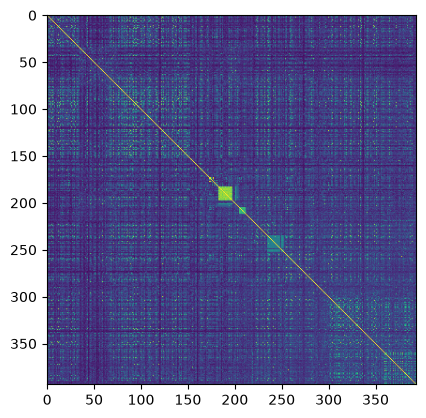

In [68]:
plt.imshow(np.nan_to_num(xcorr, nan=0.0))

In [69]:
dissimilarity = 1.0-xcorr
dissimilarity = distance.squareform(dissimilarity) #flattened version - same values as dissimilary so 1 - cc_mat

In [78]:
print('Hierarchial clustering...')
threshold = 0.3 #make this 0.2 to match the correlation detector

linkage = hierarchy.linkage(dissimilarity, method="complete",optimal_ordering=True)
clusters = hierarchy.fcluster(linkage, threshold, criterion="distance")

Hierarchial clustering...


In [79]:
print('Template matching...')
#clusters = np.load(os.path.join(c_path,'clusters_N.npz'))['clusters']
#cc_mat = np.load(os.path.join(c_path,'cc_matrix_N.npz'))['cc_mat']

full_cat = do.EventCatalogue(t1,t2,c_path)

unique, counts = np.unique(clusters,return_counts=True)
clust_ind = unique[counts > 5]

templates = {}
template_loc = {}

for i, clust_N in enumerate(clust_ind):

    cc_ind = np.where(clusters==clust_N)[0]
    temp = xcorr[cc_ind,:]
    clust_cc = temp[:,cc_ind]

    clust_events = full_cat.events.index[cc_ind]

    central_ind = np.argmax(np.mean(clust_cc,axis=1))
    central_id = clust_events[central_ind]

    templates[str(clust_N)] = central_id
    template_loc[str(clust_N)] = full_cat.events.index.get_loc(central_id)

Template matching...


In [80]:
ind = np.argsort(clusters)

temp = xcorr[ind,:]
cc_sort = temp[:,ind]

sort_temps = {}
for temp_id, temp_loc in template_loc.items():
    sort_temps[temp_id] = np.argwhere(ind==temp_loc)[0][0]

event_pos = {}
for clust_id, event_id in templates.items():
    event_pos[event_id] = sort_temps[clust_id]

ind = np.array([i for i in event_pos.values()]) #will want to sort this A-J and label these on the axes
temp = cc_sort[ind,:]
cc_temp = temp[:,ind]

dissimilarity_temp = 1-cc_temp
dissimilarity_temp = distance.squareform(dissimilarity_temp)
threshold = 0.3

linkage_temp = hierarchy.linkage(dissimilarity_temp, method="complete",optimal_ordering=True)
clusters_temp = hierarchy.fcluster(linkage_temp, threshold, criterion="distance")

In [81]:
# chunk = do.SeismicChunk(t1,t2)
# chunk.attach_waveforms(inv.select(station='TI?A',channel='CHZ'),w_path,buffer=60*60)
# chunk.decimate(5)
# #chunk.remove_response(pre_filt=[1,2,45,50],taper=False)
# chunk.filter('bandpass',freqmin=1,freqmax=30)

In [82]:
templates

{'22': '20181224T232644Z',
 '62': '20181224T080159Z',
 '74': '20181224T224402Z',
 '122': '20181224T175252Z',
 '228': '20181224T142051Z',
 '273': '20181224T095141Z'}

Text(0.5, 0, '30 seconds')

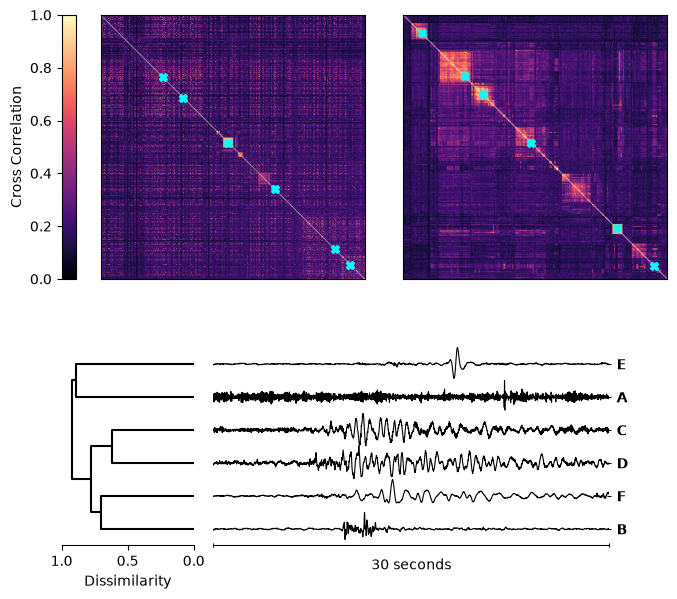

In [83]:
#now work out how to plot these nicely...

master_fig = plt.figure(figsize=(8,6))

xcorr_fig, dendro_fig = master_fig.subfigures(nrows=2,height_ratios=(2,1.5),hspace=0)

gs = xcorr_fig.add_gridspec(nrows=len(templates),ncols=3,width_ratios=[0.05,1,1],hspace=0,wspace=0.05)

cb_ax = xcorr_fig.add_subplot(gs[:,0])
chron_ax = xcorr_fig.add_subplot(gs[:,1])
sort_ax = xcorr_fig.add_subplot(gs[:,2])

cc_plot = chron_ax.imshow(xcorr,cmap='magma',vmin=0,vmax=1)
chron_ax.set_xticks([])
chron_ax.set_yticks([])

cc_plot = sort_ax.imshow(cc_sort,cmap='magma',vmin=0,vmax=1)
sort_ax.set_xticks([])
sort_ax.set_yticks([])

plt.colorbar(cc_plot,cax=cb_ax,label='Cross Correlation')
cb_ax.yaxis.set_ticks_position('left')
cb_ax.yaxis.set_label_position('left')
cb_ax.set_ylim(0,1)

i = 0
for clust_id, loc in template_loc.items():
    chron_ax.plot(loc,loc,marker='X',color='cyan')
    if i % 2 == 0:
        va = 'top'
    else:
        va = 'bottom'
    i += 1

for event_id, loc in event_pos.items():
    sort_ax.plot(loc,loc,marker='X',color='cyan')


dendro_gs = dendro_fig.add_gridspec(ncols=3,width_ratios = [1,3,0.4],wspace=0.1)
dend_ax = dendro_fig.add_subplot(dendro_gs[0])
waveform_ax = dendro_fig.add_subplot(dendro_gs[1])

labels = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y','Z']
temp_labels = {num:labels[i] for i,num in enumerate(sort_temps.keys())}
cluster_nums = [key for key in templates.keys()]


dend_ax.spines['top'].set_visible(False)
dend_ax.spines['left'].set_visible(False)
dend_ax.spines['right'].set_visible(False)



waveform_ax.spines['top'].set_visible(False)
waveform_ax.spines['left'].set_visible(False)
waveform_ax.spines['right'].set_visible(False)

hierarchy.set_link_color_palette(['darkgreen','darkred','slategrey','peru','deeppink','olive'])

dendrogram = hierarchy.dendrogram(linkage_temp,color_threshold=0,orientation='left',ax=dend_ax,labels=cluster_nums,no_labels=True,above_threshold_color='black')

dend_ax.set_xlim(1,0)
dend_ax.set_xlabel('Dissimilarity')

old_index = None
station_names = []
for i, cluster_num in enumerate(templates.keys()):
    template_id = templates[cluster_num]
    offset = 5 + i * 10

    temp_event = full_cat.select_event(template_id)
    temp_event.attach_waveforms(inv.select(station='TI3A',channel='CHZ'),w_path,buffer=10,length=25)
    temp_event.stream.decimate(5)
    temp_event.stream.filter('bandpass',freqmin=1,freqmax=30)  

    stream = temp_event.get_data_window()
    tr = stream.select(station='TI3A',channel='CHZ')[0]

    waveform_ax.plot(tr.times(),tr.data/tr.data.max()*5 + offset,lw=0.8,color='black')
    waveform_ax.set_xlim(0,30)

sorted_y_labels = [temp_labels[key] for key in dendrogram['ivl']]

waveform_ax.set_ylim((0,clusters_temp.size*10))
waveform_ax.set_yticks(np.arange(0,clusters_temp.size*10,10)+5)
waveform_ax.set_yticklabels(sorted_y_labels,weight='bold')
waveform_ax.yaxis.set_ticks_position('right')

waveform_ax.set_xticks([0,30])
waveform_ax.set_xticklabels(['',''])
waveform_ax.tick_params(direction='inout')
waveform_ax.set_xlabel('30 seconds')